# SpliceAI on CMC (COSMIC Cancer Mutation Census): splice-effect predictions

Same analysis as `spliceai_clinvar_exploration.ipynb`, applied to the CMC somatic mutation set. Loads the full SpliceAI results (`cmc_spliceai_scores.tsv`, built by `../12_variant_effect_prediction/splicing/`) -- 5,471,997 variants attempted, 5,053,736 scored (92.3%, nearly identical scoring rate to ClinVar's 92.5% -- the unscored fraction is a SpliceAI/annotation limitation, not a pipeline problem, and it's reassuringly consistent between the two independent variant sets).

**Data file is not checked into git** -- regenerate via `12_variant_effect_prediction/splicing/`, or pull `cmc_spliceai_scores.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

Unlike ClinVar, CMC's own source data is coding-mutation-only (see `12_variant_effect_prediction/README.md`), but SpliceAI itself still scores every variant's genomic context regardless -- so this table isn't restricted to exonic-only effects the way DeepLoc/protGPS's input is.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

SCORE_COLS = ["DS_AG", "DS_AL", "DS_DG", "DS_DL"]
LABELS = ["Acceptor Gain", "Acceptor Loss", "Donor Gain", "Donor Loss"]

## Load data

In [2]:
df = pd.read_csv("cmc_spliceai_scores.tsv", sep="\t")
print(f"{len(df):,} scored variants")
df.head()

5,053,736 scored variants


,GENOMIC_MUTATION_ID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
0,COSV66112854,0.0,0.00,0.0,0.03,30,29,30,29
1,COSV66110116,0.0,0.06,0.0,0.00,2,-6,2,-6
2,COSV66113302,0.0,0.02,0.0,0.00,20,-8,-8,48
3,COSV66110478,0.0,0.00,0.0,0.00,6,-34,-2,-1
4,COSV66110166,0.0,0.00,0.0,0.00,48,32,-33,-14


## Delta score distributions

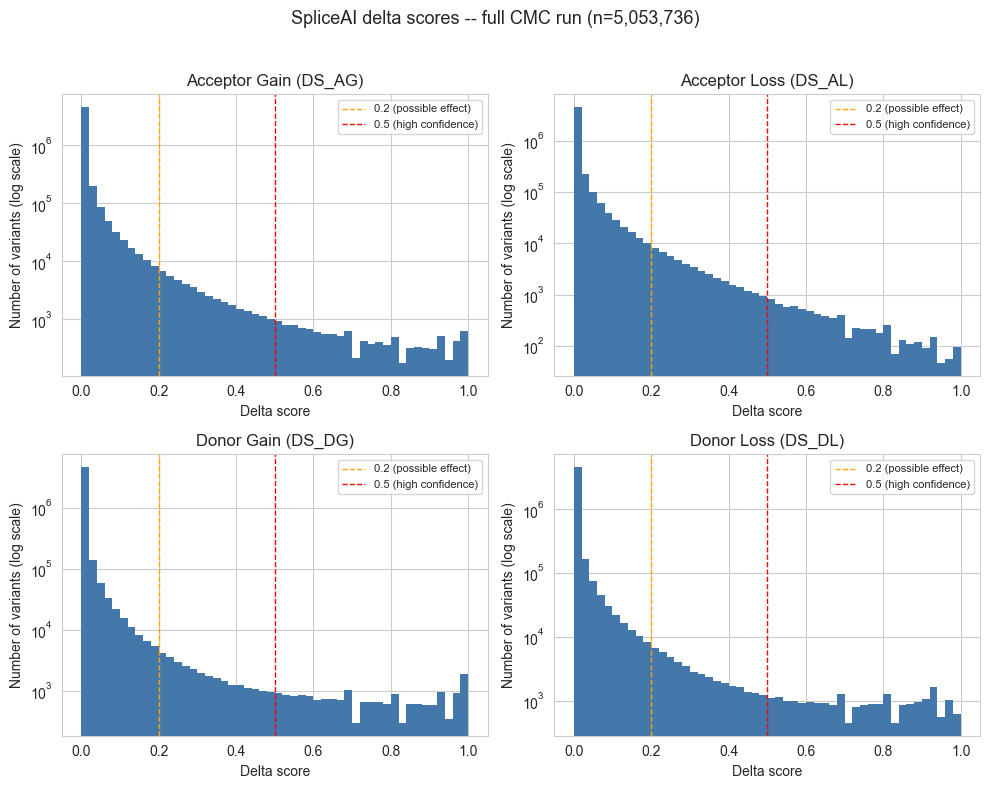

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col, label in zip(axes.flat, SCORE_COLS, LABELS):
    ax.hist(df[col], bins=50, color="#4477AA", edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(f"{label} ({col})")
    ax.set_xlabel("Delta score")
    ax.set_ylabel("Number of variants (log scale)")
    ax.axvline(0.2, color="orange", linestyle="--", linewidth=1, label="0.2 (possible effect)")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="0.5 (high confidence)")
    ax.legend(fontsize=8)
fig.suptitle(f"SpliceAI delta scores -- full CMC run (n={len(df):,})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Summary counts

In [4]:
max_score = df[SCORE_COLS].max(axis=1)
print(f"Total scored variants: {len(df):,}")
print(f"Max delta score >= 0.2 (possible splicing effect): {(max_score >= 0.2).sum():,} "
      f"({(max_score >= 0.2).mean()*100:.2f}%)")
print(f"Max delta score >= 0.5 (high-confidence effect): {(max_score >= 0.5).sum():,} "
      f"({(max_score >= 0.5).mean()*100:.2f}%)")

Total scored variants: 5,053,736
Max delta score >= 0.2 (possible splicing effect): 200,310 (3.96%)
Max delta score >= 0.5 (high-confidence effect): 57,050 (1.13%)


## Variants with the strongest predicted splicing effect

In [5]:
top_variants = df.loc[max_score.sort_values(ascending=False).index[:25]]
top_variants[["GENOMIC_MUTATION_ID"] + SCORE_COLS + ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]].head(25)

,GENOMIC_MUTATION_ID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
4596387,COSV60439813,0.00,0.00,1.0,0.27,-12,23,2,-12
1960162,COSV64251347,0.00,0.00,1.0,0.56,-2,-38,2,-37
4294680,COSV56382379,0.00,0.00,1.0,0.26,2,1,2,-26
1484104,COSV99277399,1.00,0.38,0.0,0.00,-2,-4,-4,6
1519786,COSV55164552,1.00,0.99,0.0,0.00,-2,37,-2,38
360530,COSV55004860,0.00,0.00,1.0,0.02,2,-27,2,-27
599822,COSV55167293,0.04,0.00,1.0,0.70,47,-40,2,-6
4293915,COSV113943505,0.00,0.00,1.0,0.92,-3,13,2,-2
4601538,COSV56949011,0.00,0.00,1.0,0.99,-35,-9,-2,39
2323054,COSV104565897,1.00,0.80,0.0,0.00,2,-31,26,-23
